In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd

In [ ]:
data=pd.read_csv('/content/drive/MyDrive/weather-automated-sensors-dataset.csv')

In [ ]:
print("Shape of Dataset:", data.shape)


Shape of Dataset: (59144, 18)


In [ ]:
print("First 5 rows:", data.head)

First 5 rows: <bound method NDFrame.head of                       Station Name   Measurement Timestamp  Air Temperature  \
0       Oak Street Weather Station  05/22/2015 03:00:00 PM              NaN   
1       Oak Street Weather Station  05/22/2015 05:00:00 PM              NaN   
2       Oak Street Weather Station  05/22/2015 06:00:00 PM              NaN   
3       Oak Street Weather Station  05/22/2015 07:00:00 PM              NaN   
4       Oak Street Weather Station  05/22/2015 08:00:00 PM              NaN   
...                            ...                     ...              ...   
59139   Oak Street Weather Station  11/08/2017 12:00:00 AM             4.70   
59140       Foster Weather Station  11/08/2017 12:00:00 AM             2.89   
59141  63rd Street Weather Station  11/08/2017 01:00:00 AM             3.40   
59142   Oak Street Weather Station  11/08/2017 01:00:00 AM             4.20   
59143       Foster Weather Station  11/08/2017 01:00:00 AM             2.28   

       

In [ ]:
print("\nDataset Info:")
print(data.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59144 entries, 0 to 59143
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Station Name                 59144 non-null  object 
 1   Measurement Timestamp        59141 non-null  object 
 2   Air Temperature              59066 non-null  float64
 3   Wet Bulb Temperature         38843 non-null  float64
 4   Humidity                     59141 non-null  float64
 5   Rain Intensity               38843 non-null  float64
 6   Interval Rain                59141 non-null  float64
 7   Total Rain                   38843 non-null  float64
 8   Precipitation Type           38843 non-null  float64
 9   Wind Direction               59141 non-null  float64
 10  Wind Speed                   59141 non-null  float64
 11  Maximum Wind Speed           59141 non-null  float64
 12  Barometric Pressure          58995 non-null  float64
 13  S

In [ ]:
print("\nDataset Description:\n", data.describe())



Dataset Description:
        Air Temperature  Wet Bulb Temperature      Humidity  Rain Intensity  \
count     59066.000000          38843.000000  59141.000000    38843.000000   
mean         13.282062             10.643001     69.464517        0.187591   
std           9.945331              8.965170     15.714691        1.962149   
min         -19.890000            -20.100000     17.000000        0.000000   
25%           5.500000              4.000000     59.000000        0.000000   
50%          14.900000             12.100000     71.000000        0.000000   
75%          21.500000             18.100000     82.000000        0.000000   
max          34.100000             28.400000    100.000000      183.600000   

       Interval Rain    Total Rain  Precipitation Type  Wind Direction  \
count   59141.000000  38843.000000        38843.000000    59141.000000   
mean        0.175327    185.445529            4.651932      178.980132   
std         1.300946    231.579782           16.1685

In [ ]:
print("\nChecking for Missing Values:\n", data.isnull().sum())



Checking for Missing Values:
 Station Name                       0
Measurement Timestamp              3
Air Temperature                   78
Wet Bulb Temperature           20301
Humidity                           3
Rain Intensity                 20301
Interval Rain                      3
Total Rain                     20301
Precipitation Type             20301
Wind Direction                     3
Wind Speed                         3
Maximum Wind Speed                 3
Barometric Pressure              149
Solar Radiation                    3
Heading                        20301
Battery Life                       3
Measurement Timestamp Label        3
Measurement ID                     0
dtype: int64


In [ ]:
data = data.dropna()

In [ ]:
print("\nMissing values after dropping:\n", data.isnull().sum())


Missing values after dropping:
 Station Name                   0
Measurement Timestamp          0
Air Temperature                0
Wet Bulb Temperature           0
Humidity                       0
Rain Intensity                 0
Interval Rain                  0
Total Rain                     0
Precipitation Type             0
Wind Direction                 0
Wind Speed                     0
Maximum Wind Speed             0
Barometric Pressure            0
Solar Radiation                0
Heading                        0
Battery Life                   0
Measurement Timestamp Label    0
Measurement ID                 0
dtype: int64


In [ ]:
features = data.drop(columns=['Station Name', 'Measurement Timestamp', 'Measurement Timestamp Label', 'Measurement ID', 'Air Temperature'])
target = data['Air Temperature']

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

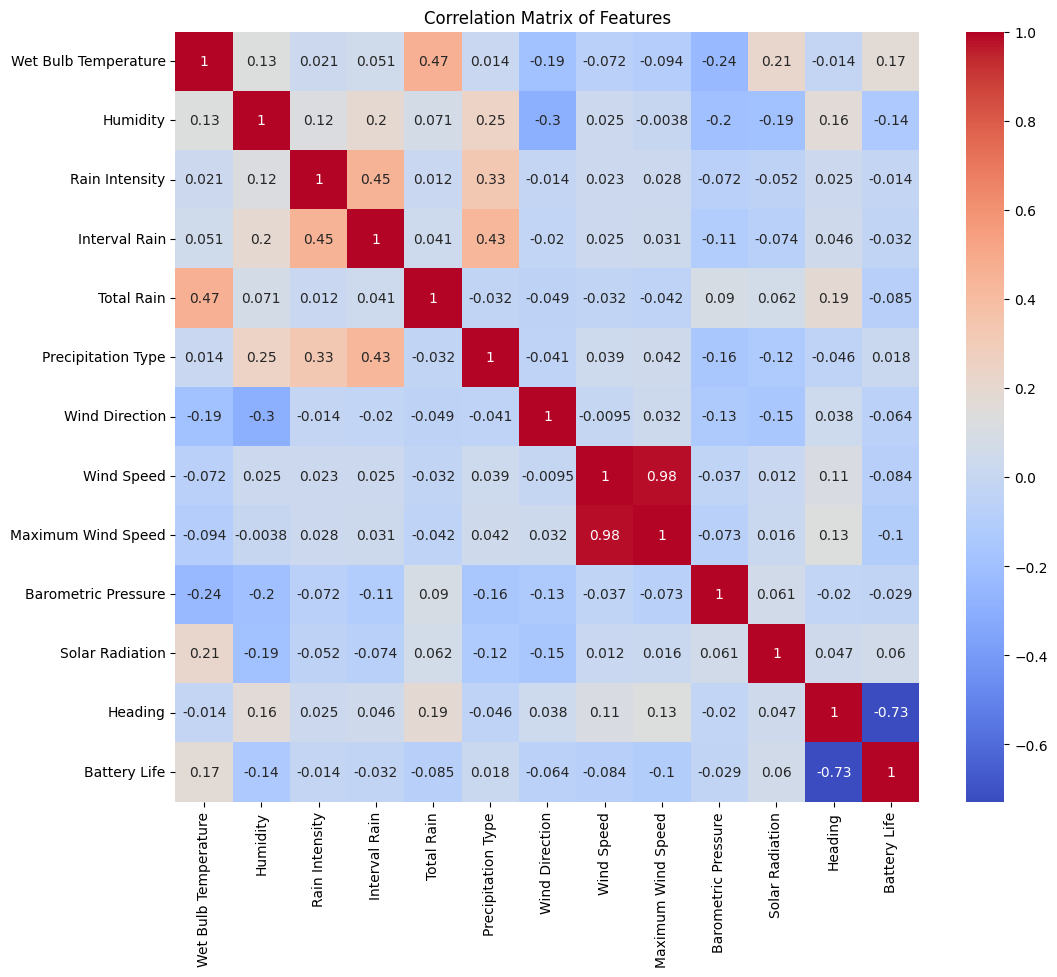

In [ ]:
plt.figure(figsize=(12, 10))
correlation = features.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix of Features")
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.ensemble import VotingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (31014, 13)
Testing Data Shape: (7754, 13)


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
#XGBoost Model Training
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb_model.fit(X_train_scaled, y_train)
xgb_pred = xgb_model.predict(X_test_scaled)

In [ ]:
#SVM Mode Training
svm_model = SVR(kernel='rbf')
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)

In [ ]:
#Ensemble Model - Voting Regressor
stacked_model = VotingRegressor([('svm', svm_model), ('xgb', xgb_model)])
stacked_model.fit(X_train_scaled, y_train)
stacked_pred = stacked_model.predict(X_test_scaled)

In [ ]:
def evaluate_model(y_test, predictions):
    mse = mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    return mse, r2

svm_mse, svm_r2 = evaluate_model(y_test, svm_pred)
xgb_mse, xgb_r2 = evaluate_model(y_test, xgb_pred)
stacked_mse, stacked_r2 = evaluate_model(y_test, stacked_pred)

In [ ]:
results = pd.DataFrame({
    'Model': ['SVM', 'XGBoost', 'Stacked Ensemble'],
    'Mean Squared Error': [svm_mse, xgb_mse, stacked_mse],
    'R^2 Score': [svm_r2, xgb_r2, stacked_r2]
})

print("\nSummary of Model Performance:")
print(results)


Summary of Model Performance:
              Model  Mean Squared Error  R^2 Score
0               SVM            0.221303   0.997779
1           XGBoost            0.031242   0.999686
2  Stacked Ensemble            0.065202   0.999345


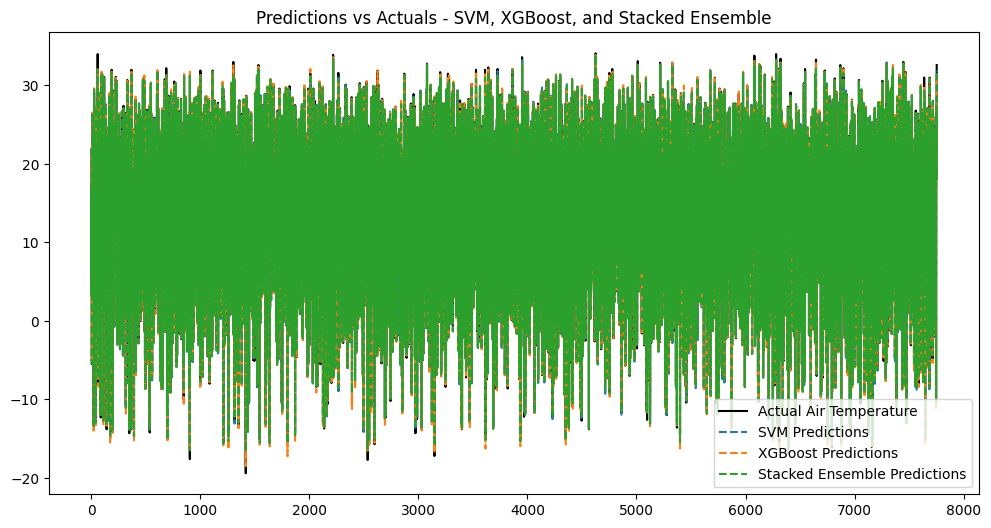

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label="Actual Air Temperature", color='black')
plt.plot(svm_pred, label="SVM Predictions", linestyle='--')
plt.plot(xgb_pred, label="XGBoost Predictions", linestyle='--')
plt.plot(stacked_pred, label="Stacked Ensemble Predictions", linestyle='--')
plt.legend()
plt.title("Predictions vs Actuals - SVM, XGBoost, and Stacked Ensemble")
plt.show()

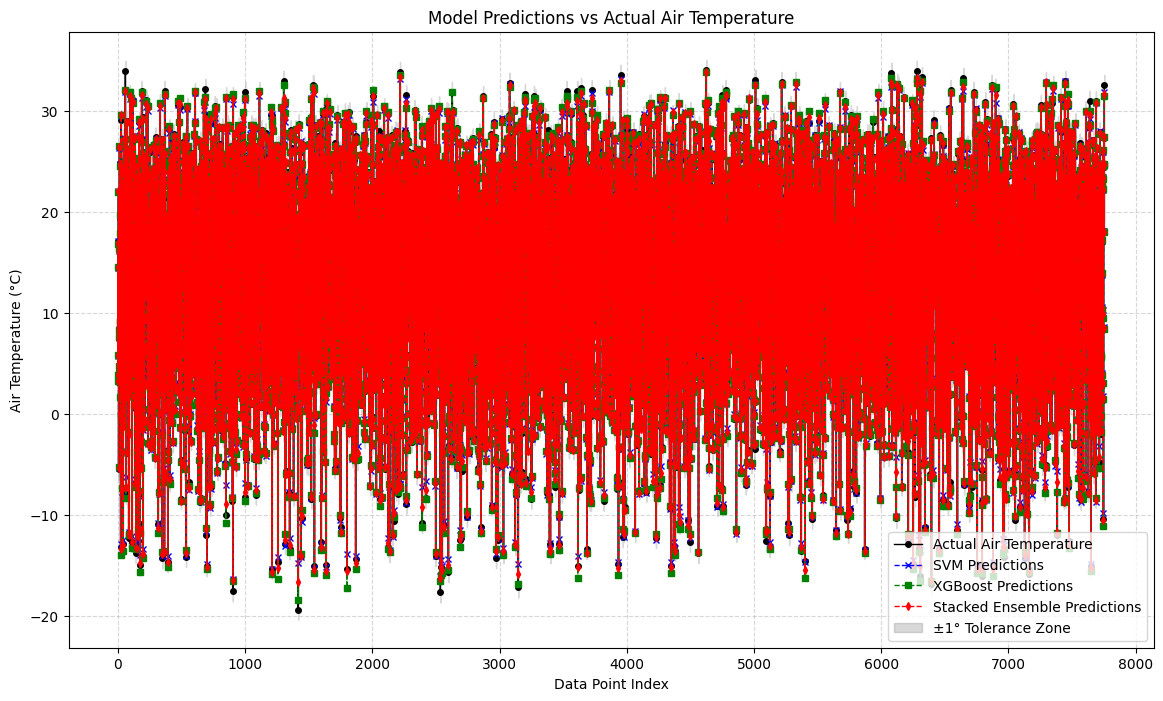

In [ ]:
plt.figure(figsize=(14, 8))
plt.plot(y_test.values, label="Actual Air Temperature", color='black', marker='o', markersize=4, linewidth=1)
plt.plot(svm_pred, label="SVM Predictions", color='blue', linestyle='--', marker='x', markersize=4, linewidth=1)
plt.plot(xgb_pred, label="XGBoost Predictions", color='green', linestyle='--', marker='s', markersize=4, linewidth=1)
plt.plot(stacked_pred, label="Stacked Ensemble Predictions", color='red', linestyle='--', marker='d', markersize=4, linewidth=1)

plt.fill_between(range(len(y_test)), y_test.values - 1, y_test.values + 1, color='gray', alpha=0.3, label="±1° Tolerance Zone")
plt.legend()
plt.xlabel("Data Point Index")
plt.ylabel("Air Temperature (°C)")
plt.title("Model Predictions vs Actual Air Temperature")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


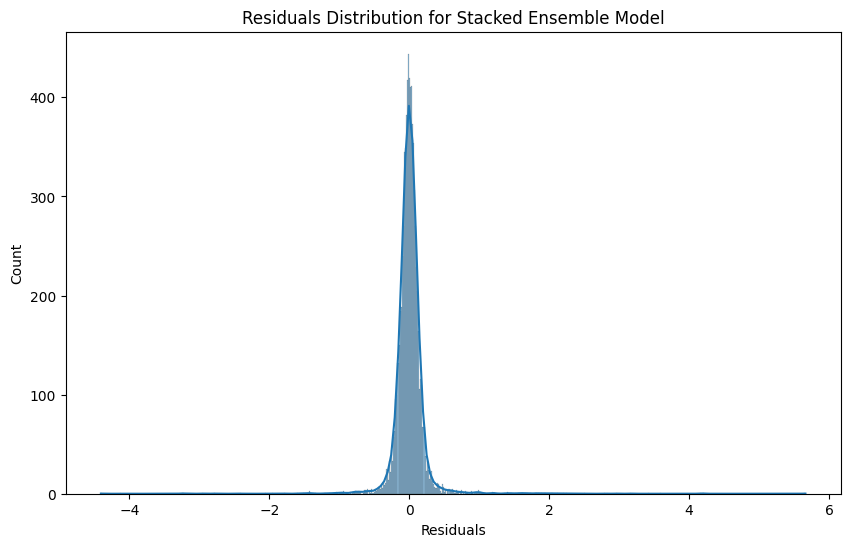

In [ ]:
residuals = y_test - stacked_pred
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.title("Residuals Distribution for Stacked Ensemble Model")
plt.xlabel("Residuals")
plt.show()

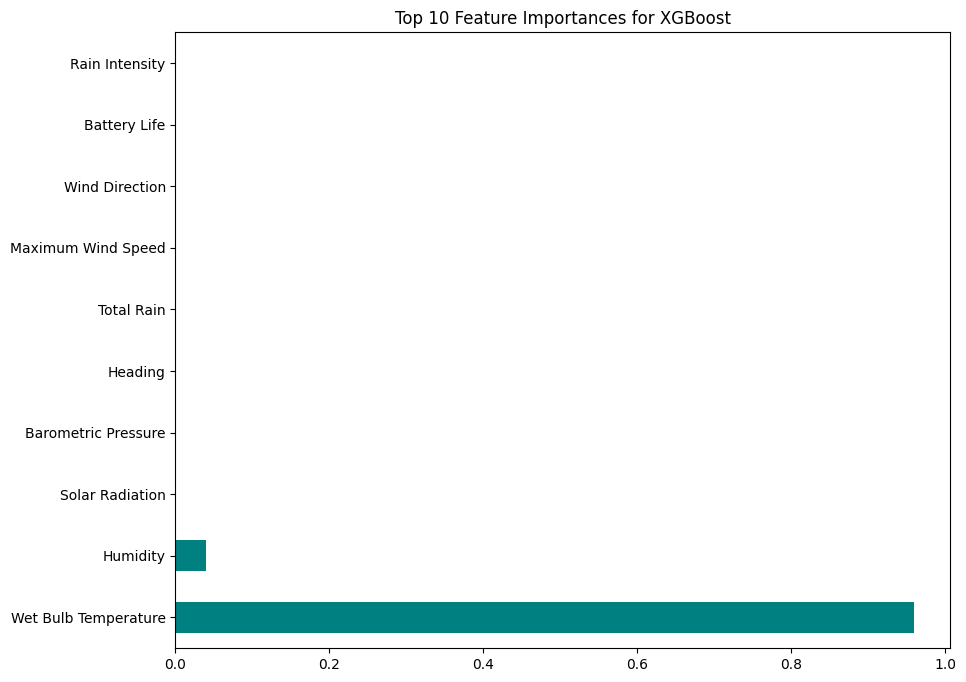

In [ ]:
plt.figure(figsize=(10, 8))
xgb_importances = pd.Series(xgb_model.feature_importances_, index=features.columns)
xgb_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title("Top 10 Feature Importances for XGBoost")
plt.show()


In [ ]:
cv_scores = cross_val_score(stacked_model, X_train_scaled, y_train, cv=5, scoring='r2')
print("\nCross-Validation R^2 Scores:", cv_scores)
print("Mean Cross-Validation R^2 Score:", cv_scores.mean())



Cross-Validation R^2 Scores: [0.99925149 0.99868207 0.99863199 0.9989173  0.9991224 ]
Mean Cross-Validation R^2 Score: 0.9989210508768865


In [ ]:
from sklearn.model_selection import GridSearchCV


In [ ]:
# Hyperparameter tuning for SVM
svm_params = {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'rbf']}
svm_grid = GridSearchCV(SVR(), svm_params, cv=3)
svm_grid.fit(X_train_scaled, y_train)
print("Best SVM Params:", svm_grid.best_params_)

Best SVM Params: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}


In [ ]:
# Hyperparameter tuning for XGBoost
xgb_params = {'n_estimators': [50, 100], 'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, 7]}
xgb_grid = GridSearchCV(XGBRegressor(random_state=42), xgb_params, cv=3)
xgb_grid.fit(X_train_scaled, y_train)
print("Best XGBoost Params:", xgb_grid.best_params_)

Best XGBoost Params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100}


In [ ]:
svm_best = svm_grid.best_estimator_
xgb_best = xgb_grid.best_estimator_

In [ ]:
stacked_model_tuned = VotingRegressor([('svm', svm_best), ('xgb', xgb_best)])
stacked_model_tuned.fit(X_train_scaled, y_train)

VotingRegressor(estimators=[('svm', SVR(C=10, gamma='auto')),
                            ('xgb',
                             XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          gamma=None, grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints=None,
                                          learning_rate=0.1, max_bin=None,
                                          max_cat_threshold=None,
                                          max_cat_to_onehot=None,
                                          max_delta_step=None, max_depth=7,
                                          max_leaves=None,
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None, n_estimators=100,
                                          n_jobs=None, num_parallel_tree=None,
                                          random_state=42, ...))])

In [ ]:
stacked_tuned_pred = stacked_model_tuned.predict(X_test_scaled)
stacked_tuned_mse, stacked_tuned_r2 = evaluate_model(y_test, stacked_tuned_pred)

print(f"\nStacked Ensemble Tuned - MSE: {stacked_tuned_mse:.6f}, R^2: {stacked_tuned_r2:.6f}")



Stacked Ensemble Tuned - MSE: 0.022330, R^2: 0.999776


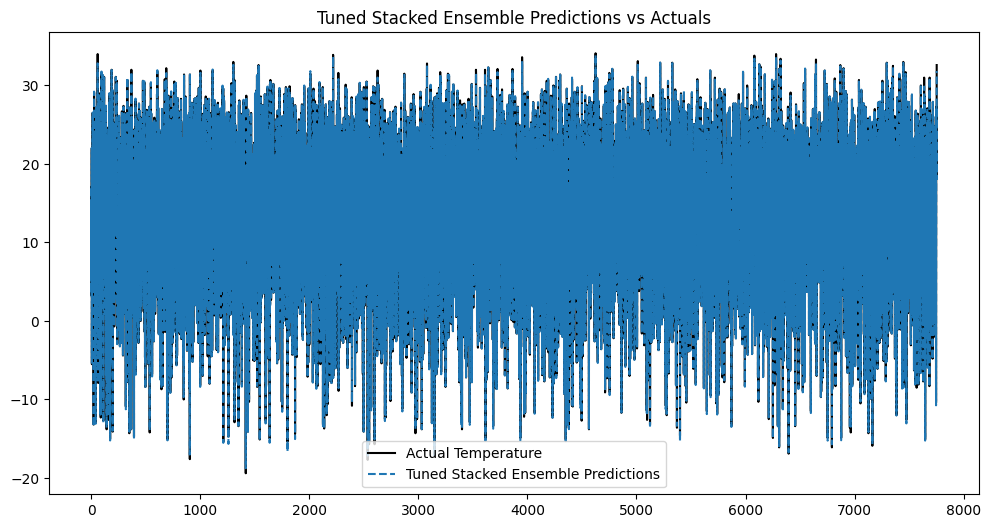

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label="Actual Temperature", color='black')
plt.plot(stacked_tuned_pred, label="Tuned Stacked Ensemble Predictions", linestyle='--')
plt.legend()
plt.title("Tuned Stacked Ensemble Predictions vs Actuals")
plt.show()

In [ ]:
tuned_results = pd.DataFrame({
    'Model': ['SVM', 'XGBoost', 'Original Stacked Ensemble', 'Tuned Stacked Ensemble'],
    'Mean Squared Error': [svm_mse, xgb_mse, stacked_mse, stacked_tuned_mse],
    'R^2 Score': [svm_r2, xgb_r2, stacked_r2, stacked_tuned_r2]
})

print("\nFinal Performance Comparison:")
print(tuned_results)


Final Performance Comparison:
                       Model  Mean Squared Error  R^2 Score
0                        SVM            0.221303   0.997779
1                    XGBoost            0.031242   0.999686
2  Original Stacked Ensemble            0.065202   0.999345
3     Tuned Stacked Ensemble            0.022330   0.999776
